# Car Price Prediction

## Project Overview

This project develops a machine learning model to predict used car selling prices based on vehicle characteristics such as present price, year, kilometers driven, fuel type, selling type, transmission, and ownership.

A Random Forest Regression model is used after preprocessing the numerical and categorical features. The model is evaluated using MAE, RMSE, and R² score.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [24]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [25]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (301, 9)

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [26]:
print("Fuel Types:")
print(df["Fuel_Type"].value_counts())

print("\nSelling Types:")
print(df["Selling_type"].value_counts())

print("\nTransmission Types:")
print(df["Transmission"].value_counts())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling Types:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission Types:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [27]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [28]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [29]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after removing duplicates: (299, 9)
Duplicate rows remaining: 0


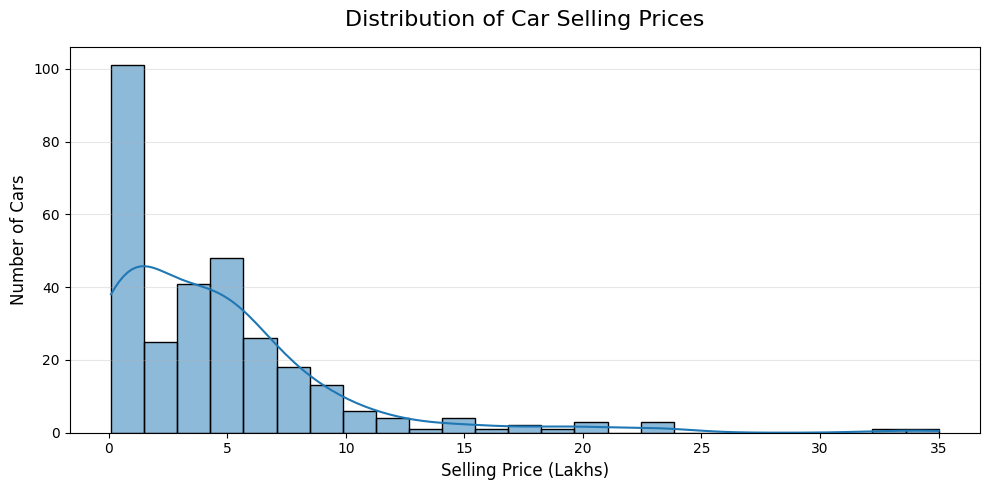

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Selling_Price"],
    bins=25,
    kde=True
)

plt.title("Distribution of Car Selling Prices", fontsize=16, pad=15)
plt.xlabel("Selling Price (Lakhs)", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

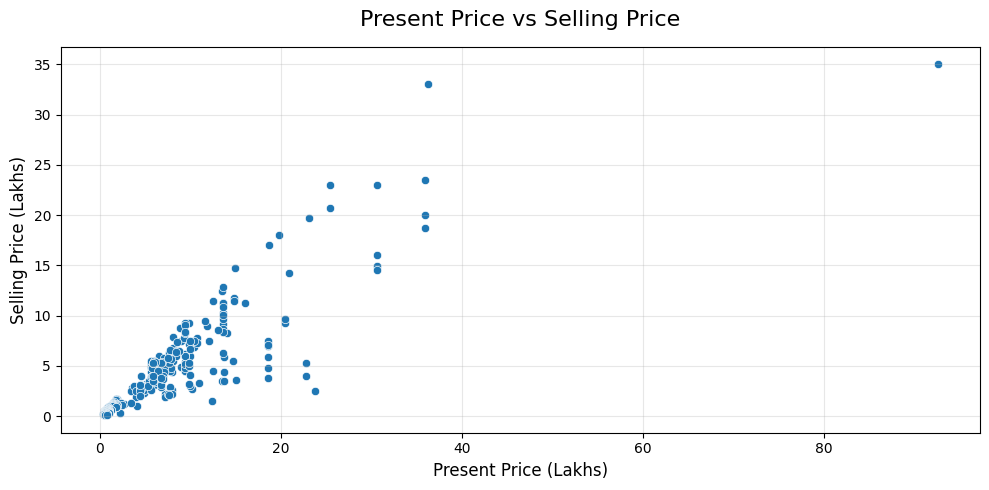

In [31]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price", fontsize=16, pad=15)
plt.xlabel("Present Price (Lakhs)", fontsize=12)
plt.ylabel("Selling Price (Lakhs)", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

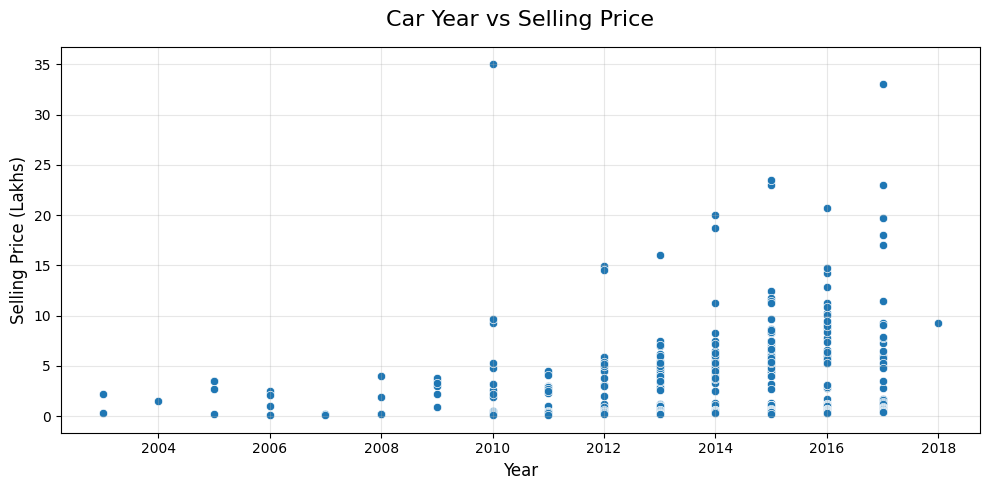

In [32]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price"
)

plt.title("Car Year vs Selling Price", fontsize=16, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Selling Price (Lakhs)", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# Car_Name is dropped because it is a high-cardinality categorical feature
X = X.drop("Car_Name", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 239
Testing samples: 60


In [34]:
numeric_features = ["Year", "Present_Price", "Driven_kms", "Owner"]
categorical_features = ["Fuel_Type", "Selling_type", "Transmission"]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Year', 'Present_Price', 'Driven_kms', 'Owner']
Categorical features: ['Fuel_Type', 'Selling_type', 'Transmission']


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [36]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

print("Random Forest regression pipeline created successfully.")

Random Forest regression pipeline created successfully.


In [37]:
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [38]:
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 60


In [39]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} lakhs")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} lakhs")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 1.49 lakhs
Root Mean Squared Error (RMSE): 3.54 lakhs
R² Score: 0.51


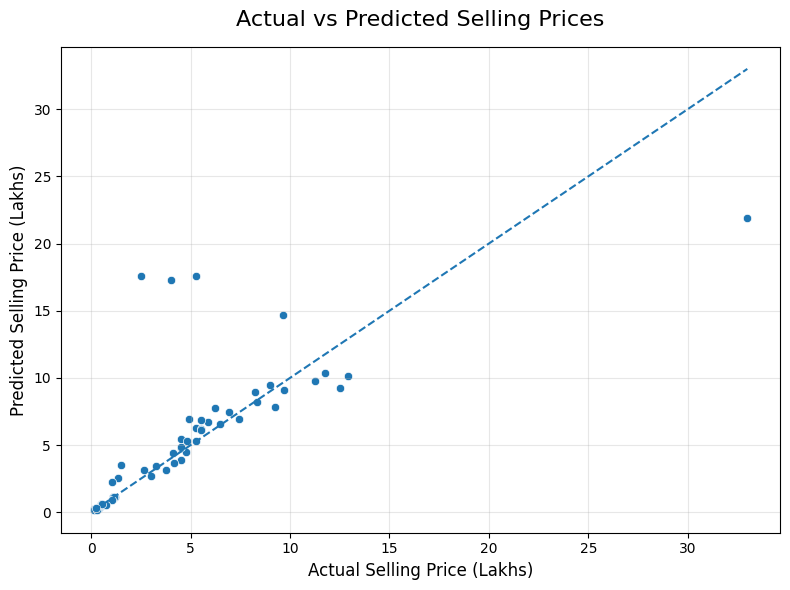

In [40]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Selling Prices", fontsize=16, pad=15)
plt.xlabel("Actual Selling Price (Lakhs)", fontsize=12)
plt.ylabel("Predicted Selling Price (Lakhs)", fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,num__Present_Price,0.903723
0,num__Year,0.071052
2,num__Driven_kms,0.013256
9,cat__Transmission_Automatic,0.004104
10,cat__Transmission_Manual,0.003665
8,cat__Selling_type_Individual,0.001139
5,cat__Fuel_Type_Diesel,0.001049
7,cat__Selling_type_Dealer,0.001044
6,cat__Fuel_Type_Petrol,0.000958
3,num__Owner,0.000008


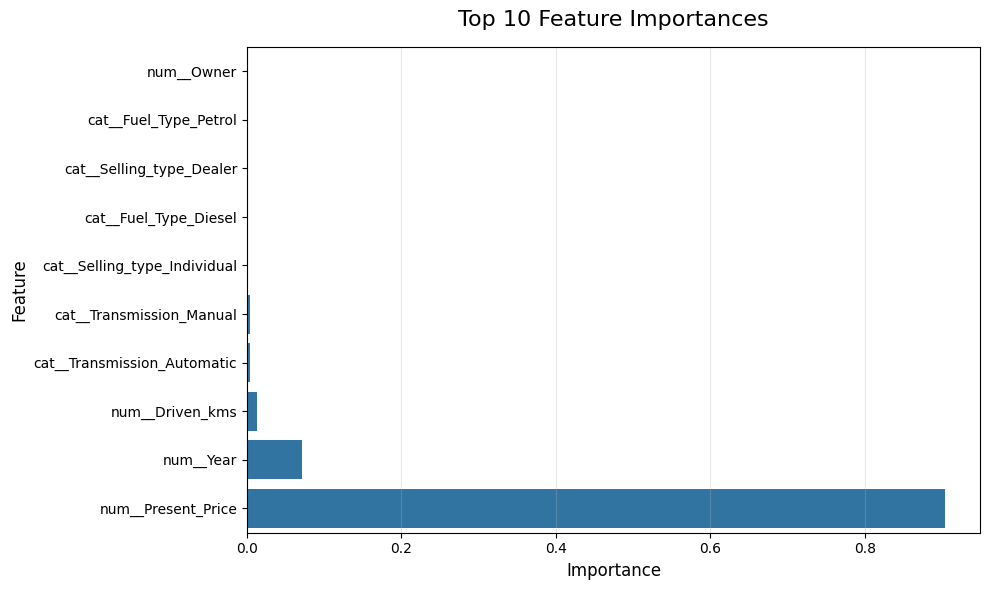

In [42]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances", fontsize=16, pad=15)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Key Insights

- The dataset contains 299 car records after removing duplicate entries.
- Car selling prices are strongly right-skewed, with most cars priced below ₹10 lakhs.
- Present Price shows a strong positive relationship with Selling Price.
- Newer cars generally have higher selling prices than older cars.
- Present Price is the most influential feature in the Random Forest model, contributing approximately 90% of total feature importance.
- The model achieved an MAE of 1.49 lakhs, RMSE of 3.54 lakhs, and an R² score of 0.51 on the test set.
- The model performs reasonably well for many cars but shows larger errors for some higher-priced vehicles.

## Conclusion

A Random Forest Regression model was developed to predict used car selling prices based on vehicle characteristics. The model achieved an R² score of 0.51 on the test dataset, with an MAE of 1.49 lakhs and an RMSE of 3.54 lakhs.

The analysis shows that Present Price and Year are the most influential factors in predicting car selling prices. The project demonstrates how machine learning can be applied to estimate used car prices from historical vehicle data.